# Gradient Descent + K-Means Learning Rules (Epochs, Iterations, Examples)
This notebook explains **gradient descent** and **k-means clustering** using clean mental models and runnable code.

## You will learn
- What an **objective function** is
- What **gradient descent** does (batch, SGD, mini-batch)
- What **learning rate** and **epochs** mean
- How k-means is an **iterative learning rule** (assign → update)
- How to debug common issues (divergence, bad initialization, local minima)

> Works in Google Colab / Jupyter.


## 0) Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

---
# 1) Clean mental model: optimization in ML
Most ML training problems look like:

$$
\min_{\theta} \; J(\theta)
$$

- \(\theta\) are parameters (weights)
- \(J(\theta)\) is the objective (loss)

### Gradient descent intuition
Imagine \(J(\theta)\) is a landscape. The gradient \(\nabla J(\theta)\) points uphill.
Gradient descent moves **downhill**:

$$
\theta \leftarrow \theta - \eta \, \nabla J(\theta)
$$

- \(\eta\) = learning rate (step size)


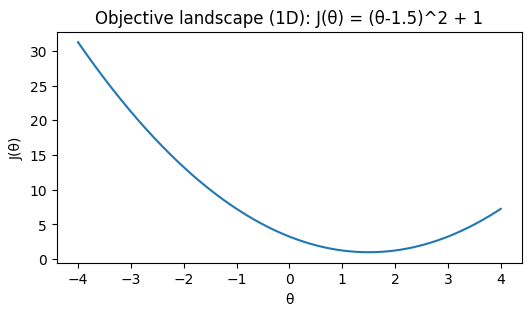

In [ ]:
# Visual intuition: 1D quadratic function
theta = np.linspace(-4, 4, 400)
J = (theta - 1.5)**2 + 1

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(theta, J)
ax.set_title("Objective landscape (1D): J(θ) = (θ-1.5)^2 + 1")
ax.set_xlabel("θ")
ax.set_ylabel("J(θ)")
plt.show()

---
# 2) What is an epoch? What is an iteration?
These words are used differently depending on context.

### In supervised learning with gradient descent
- **Iteration / step**: one parameter update
- **Epoch**: one full pass through the training data

If you have \(N\) training examples and batch size \(B\):
- steps per epoch \(= \lceil N/B \rceil\)

### In k-means clustering
- We usually say **iteration** rather than epoch.
- One iteration = assign points to clusters + update centers (a full pass).


---
# 3) Gradient Descent from scratch (Linear Regression)
### What we're trying to do
Fit a line \(\hat{y} = w x + b\) by minimizing mean squared error (MSE).

$$
J(w,b) = \frac{1}{N}\sum_{i=1}^N (y_i - (wx_i + b))^2
$$

### Learning rule (gradients)
$$
\frac{\partial J}{\partial w} = -\frac{2}{N}\sum x_i\,(y_i-\hat{y}_i)\qquad
\frac{\partial J}{\partial b} = -\frac{2}{N}\sum (y_i-\hat{y}_i)
$$

### Expected output
- Loss decreases over epochs for a good learning rate
- Learned line matches the trend


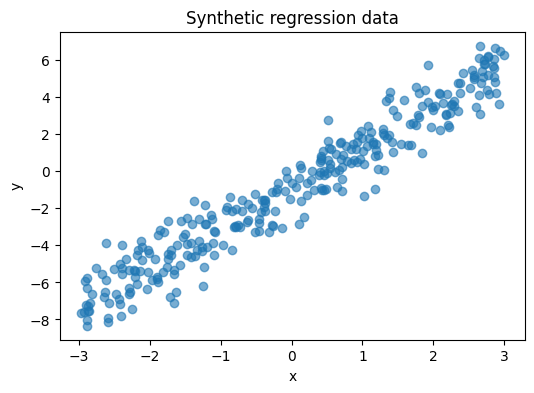

In [ ]:
# Generate simple linear data
N = 300
X = np.random.uniform(-3, 3, size=N)
true_w, true_b = 2.2, -0.8
y = true_w * X + true_b + np.random.normal(0, 1.0, size=N)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X, y, alpha=0.6)
ax.set_title("Synthetic regression data")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

In [ ]:
def batch_gradient_descent_linear(X, y, lr=0.05, epochs=200):
    w = 0.0
    b = 0.0
    N = len(X)
    history = []

    for epoch in range(epochs):
        yhat = w * X + b
        err = y - yhat
        loss = np.mean(err**2)

        dw = -(2.0/N) * np.sum(X * err)
        db = -(2.0/N) * np.sum(err)

        w -= lr * dw
        b -= lr * db

        history.append({"epoch": epoch, "loss": loss, "w": w, "b": b})

    return w, b, pd.DataFrame(history)

w_fit, b_fit, hist = batch_gradient_descent_linear(X, y, lr=0.05, epochs=200)
w_fit, b_fit, hist.head()

(np.float64(2.15168278940307),
 np.float64(-0.9041467235753058),
    epoch       loss         w         b
 0      0  15.735887  0.649591 -0.085893
 1      1   8.431640  1.102678 -0.164562
 2      2   4.828374  1.418744 -0.236316
 3      3   3.034118  1.639261 -0.301558
 4      4   2.127316  1.793147 -0.360740)

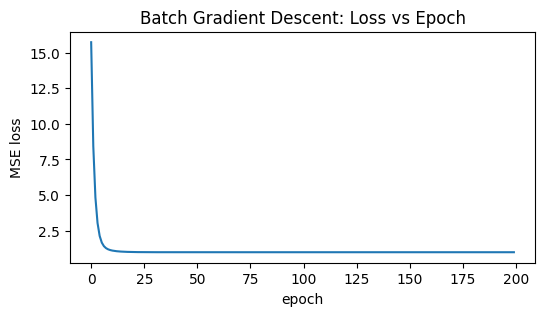

True w,b : 2.2 -0.8
Learned w,b: 2.1517 -0.9041


In [ ]:
# Plot loss over epochs
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(hist["epoch"], hist["loss"])
ax.set_title("Batch Gradient Descent: Loss vs Epoch")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
plt.show()

print("True w,b :", true_w, true_b)
print("Learned w,b:", round(w_fit, 4), round(b_fit, 4))

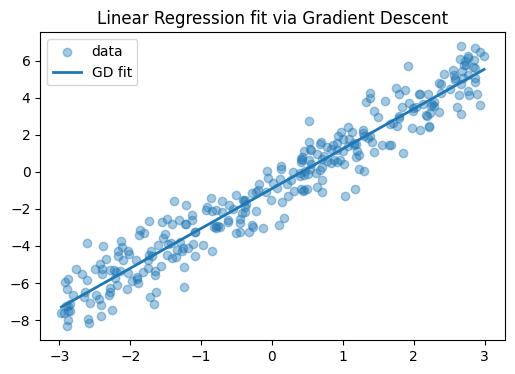

In [ ]:
# Plot fitted line
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X, y, alpha=0.4, label="data")
xs = np.linspace(X.min(), X.max(), 200)
ax.plot(xs, w_fit*xs + b_fit, linewidth=2, label="GD fit")
ax.set_title("Linear Regression fit via Gradient Descent")
ax.legend()
plt.show()

---
# 4) Learning rate: too small vs too large
### What we're trying to do
Show how learning rate affects convergence.

### Expected output
- Small lr: slow but stable
- Medium lr: fast convergence
- Large lr: divergence (loss explodes)


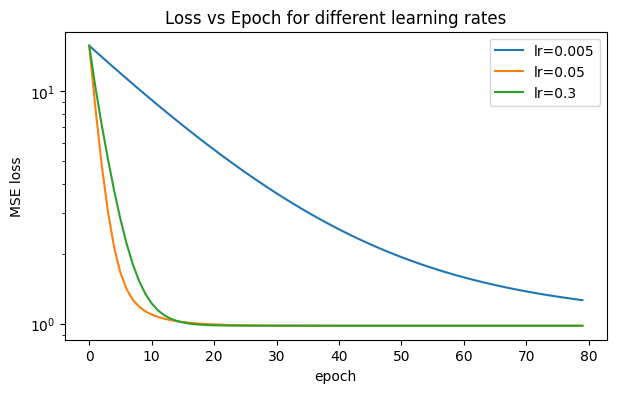

In [ ]:
lrs = [0.005, 0.05, 0.3]
fig, ax = plt.subplots(figsize=(7,4))

for lr in lrs:
    _, _, h = batch_gradient_descent_linear(X, y, lr=lr, epochs=80)
    ax.plot(h["epoch"], h["loss"], label=f"lr={lr}")

ax.set_title("Loss vs Epoch for different learning rates")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss")
ax.set_yscale("log")
ax.legend()
plt.show()

---
# 5) SGD vs Mini-batch vs Batch
### Clean definition
- **Batch GD**: uses all data → smooth updates
- **SGD**: uses 1 example → noisy updates
- **Mini-batch**: uses B examples → most common

### Expected output
- SGD/mini-batch curves are noisier
- Batch is smoother


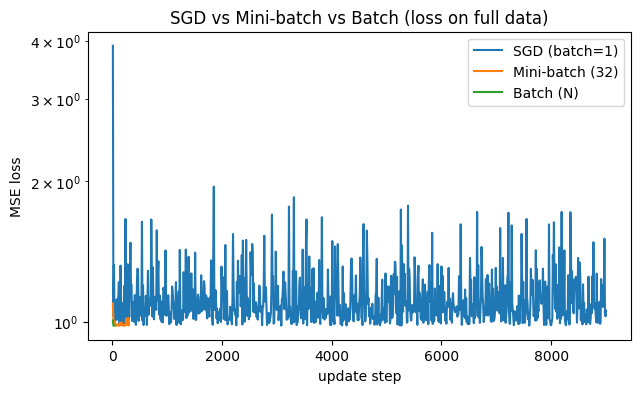

In [ ]:
def minibatch_gd_linear(X, y, lr=0.05, epochs=30, batch_size=32, shuffle=True):
    w = 0.0
    b = 0.0
    N = len(X)
    history = []
    steps = 0

    for epoch in range(epochs):
        idx = np.arange(N)
        if shuffle:
            np.random.shuffle(idx)

        for start in range(0, N, batch_size):
            batch_idx = idx[start:start+batch_size]
            xb = X[batch_idx]
            yb = y[batch_idx]

            yhat = w*xb + b
            err = yb - yhat

            dw = -(2.0/len(xb)) * np.sum(xb * err)
            db = -(2.0/len(xb)) * np.sum(err)

            w -= lr * dw
            b -= lr * db
            steps += 1

            if steps % 10 == 0:
                full_err = y - (w*X + b)
                history.append({"step": steps, "epoch": epoch, "loss": np.mean(full_err**2)})

    return w, b, pd.DataFrame(history)

w_sgd, b_sgd, h_sgd = minibatch_gd_linear(X, y, lr=0.03, epochs=30, batch_size=1)
w_mb,  b_mb,  h_mb  = minibatch_gd_linear(X, y, lr=0.05, epochs=30, batch_size=32)
w_bg,  b_bg,  h_bg  = minibatch_gd_linear(X, y, lr=0.08, epochs=30, batch_size=len(X))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(h_sgd["step"], h_sgd["loss"], label="SGD (batch=1)")
ax.plot(h_mb["step"],  h_mb["loss"],  label="Mini-batch (32)")
ax.plot(h_bg["step"],  h_bg["loss"],  label="Batch (N)")
ax.set_title("SGD vs Mini-batch vs Batch (loss on full data)")
ax.set_xlabel("update step")
ax.set_ylabel("MSE loss")
ax.set_yscale("log")
ax.legend()
plt.show()

---
# 6) K-Means clustering as an iterative learning rule
### Objective
$$
J(\{\mu_k\}) = \sum_{i=1}^N \min_{k \in \{1..K\}} \|x_i - \mu_k\|^2
$$

### Learning rule (2-step iteration)
**(A) Assignment**:
$$
c_i \leftarrow \arg\min_k \|x_i - \mu_k\|^2
$$

**(B) Update**:
$$
\mu_k \leftarrow \frac{1}{|C_k|}\sum_{i: c_i=k} x_i
$$

### Expected output
- Centroids move each iteration
- Objective decreases each iteration


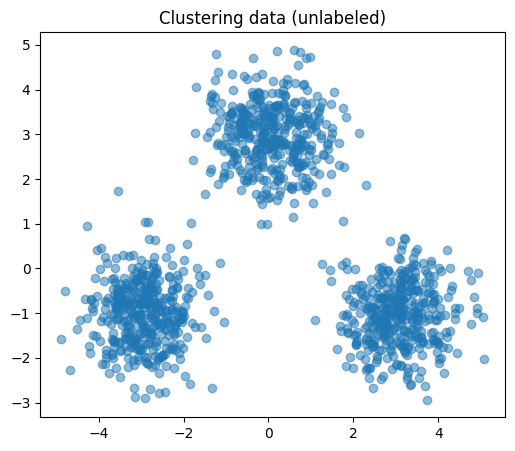

In [ ]:
# Create a clustering dataset (3 blobs)
centers = np.array([[-3, -1], [0, 3], [3, -1]])
Xc = np.vstack([
    np.random.normal(loc=centers[0], scale=0.7, size=(400,2)),
    np.random.normal(loc=centers[1], scale=0.7, size=(400,2)),
    np.random.normal(loc=centers[2], scale=0.7, size=(400,2)),
])

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(Xc[:,0], Xc[:,1], alpha=0.5)
ax.set_title("Clustering data (unlabeled)")
plt.show()

In [ ]:
def kmeans_from_scratch(X, K=3, iters=10, init="kmeans++"):
    N, D = X.shape

    # init
    if init == "random":
        idx = np.random.choice(N, size=K, replace=False)
        mu = X[idx].copy()
    elif init == "kmeans++":
        mu = [X[np.random.randint(N)]]
        for _ in range(1, K):
            dist2 = np.min([np.sum((X - m)**2, axis=1) for m in mu], axis=0)
            probs = dist2 / (dist2.sum() + 1e-12)
            mu.append(X[np.random.choice(N, p=probs)])
        mu = np.array(mu)
    else:
        raise ValueError("init must be 'random' or 'kmeans++'")

    history = []
    for t in range(iters):
        dist2 = np.stack([np.sum((X - mu[k])**2, axis=1) for k in range(K)], axis=1)
        c = np.argmin(dist2, axis=1)
        J = np.sum(np.min(dist2, axis=1))
        history.append({"iter": t, "J": J, "mu": mu.copy(), "c": c.copy()})

        new_mu = mu.copy()
        for k in range(K):
            pts = X[c == k]
            if len(pts) > 0:
                new_mu[k] = pts.mean(axis=0)
        mu = new_mu

    Jhist = pd.DataFrame([{"iter": h["iter"], "J": h["J"]} for h in history])
    return mu, c, Jhist, history

mu_final, c_final, Jhist, hist_k = kmeans_from_scratch(Xc, K=3, iters=12, init="kmeans++")
Jhist.head(), mu_final

(   iter            J
 0     0  2235.830154
 1     1  1181.324430
 2     2  1181.150596
 3     3  1181.150596
 4     4  1181.150596,
 array([[-2.95389283, -0.99558189],
        [ 0.05964154,  2.96983798],
        [ 3.05707199, -1.0363152 ]]))

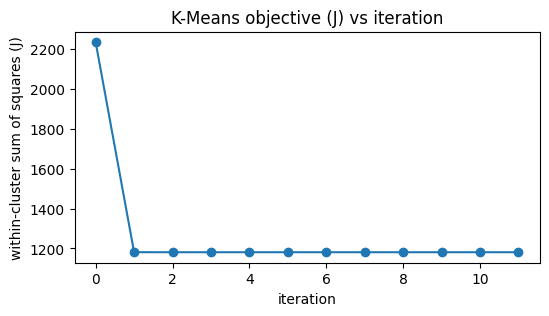

In [ ]:
# Plot objective vs iteration
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(Jhist["iter"], Jhist["J"], marker="o")
ax.set_title("K-Means objective (J) vs iteration")
ax.set_xlabel("iteration")
ax.set_ylabel("within-cluster sum of squares (J)")
plt.show()

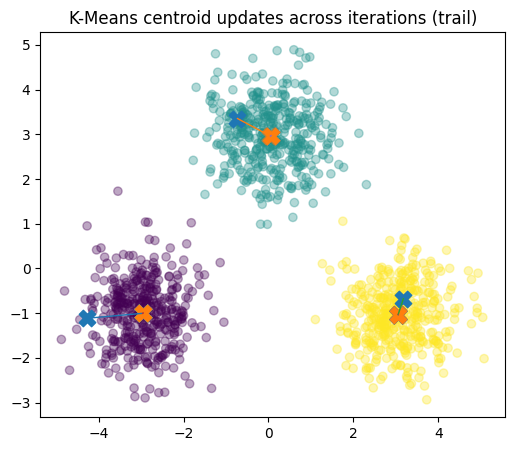

In [ ]:
# Visualize center movement across iterations
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(Xc[:,0], Xc[:,1], c=c_final, alpha=0.35)

for t, h in enumerate(hist_k):
    mu = h["mu"]
    ax.scatter(mu[:,0], mu[:,1], s=140, marker="X")
    if t > 0:
        prev = hist_k[t-1]["mu"]
        for k in range(mu.shape[0]):
            ax.plot([prev[k,0], mu[k,0]], [prev[k,1], mu[k,1]], linewidth=1)

ax.set_title("K-Means centroid updates across iterations (trail)")
plt.show()

---
# 7) Quick comparison + practical tips
## GD vs k-means
- **Gradient descent** takes *small steps* controlled by a learning rate.
- **K-means** jumps centroids directly to the mean of assigned points.

## Common pitfalls
- GD: learning rate too high → divergence; too low → slow
- K-means: poor initialization → worse local optimum; empty clusters

## Practical tips
- Scale features for both GD-heavy models (SVM/NN) and k-means.
- For k-means, use k-means++ and multiple restarts.
